<a href="https://colab.research.google.com/github/ramialnajdi/Gold-Prices-Forecasting/blob/main/Gold_Prices_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time series forecasting using Statistical Modeling - Machine learning - Deep learning

In [ ]:
!pip install statsforecast
!pip install mlforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.4/354.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.8/285.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.3/135.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 13.4 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Detect how much data we want in historical data (ex. two year of data)
num_of_years = 2
# Get end date
end_date = datetime(2024, 8, 6)
# Get start date
state_date = end_date - timedelta(days=365*num_of_years)
# Ticker symbol
gold_ticker = 'GC=F'
# Fetch historical gold data as pandas dataframe
df = yf.download(gold_ticker, start=state_date, end=end_date)
# Get only Close price column
df = df[["Close"]]

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [ ]:
# display the dataset
df.head()

Price,Close
Ticker,GC=F
Date,
2022-08-08,1786.800049
2022-08-09,1794.000000
2022-08-10,1795.599976
2022-08-11,1789.699951
2022-08-12,1798.599976


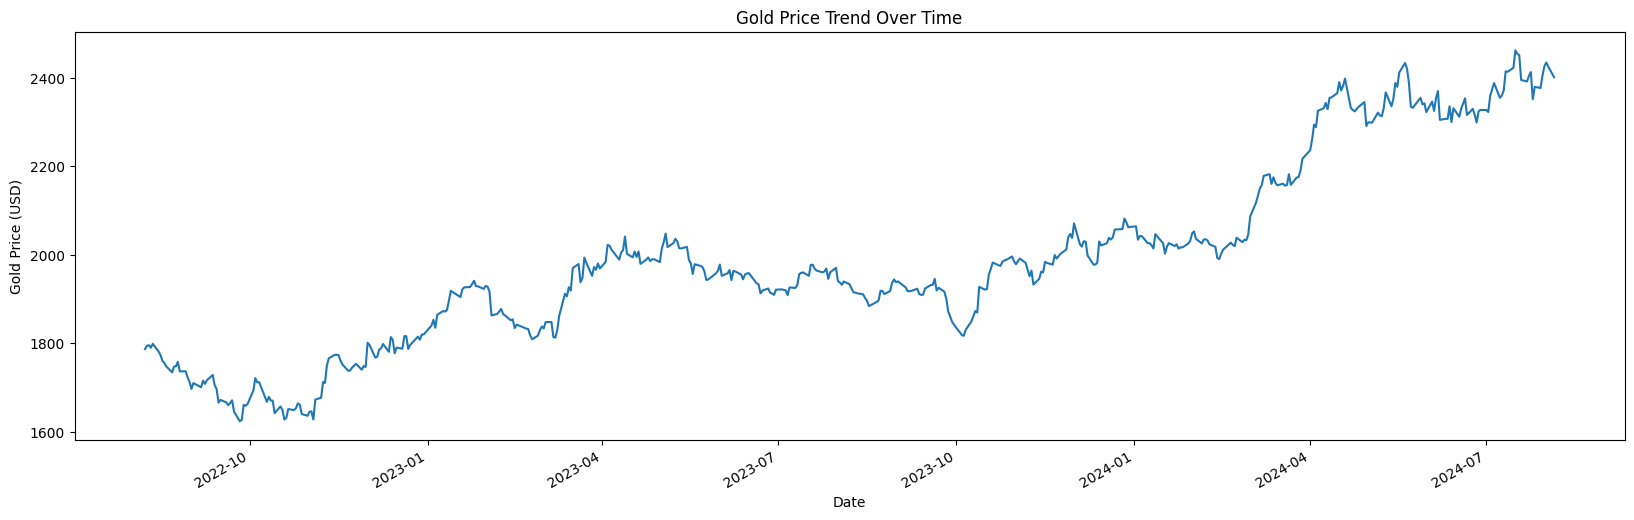

In [ ]:
fig = df.plot(kind='line', legend=False, figsize=(20, 6), title='Gold Price Trend Over Time')
plt.ylabel('Gold Price (USD)')
plt.savefig('data.eps')
plt.show()

In [ ]:
# Data processing
data = pd.DataFrame({'unique_id':[1]*len(df),
                   'ds': df.index,
                   'y':df['Close'].reset_index(drop=True).values.flatten()})

In [ ]:
data.head()

,unique_id,ds,y
0,1,2022-08-08,1786.800049
1,1,2022-08-09,1794.000000
2,1,2022-08-10,1795.599976
3,1,2022-08-11,1789.699951
4,1,2022-08-12,1798.599976


In [ ]:
# Split the data into training and test sets
train_size = int(0.8 * len(df))
train, test = data[:train_size], data[train_size:]

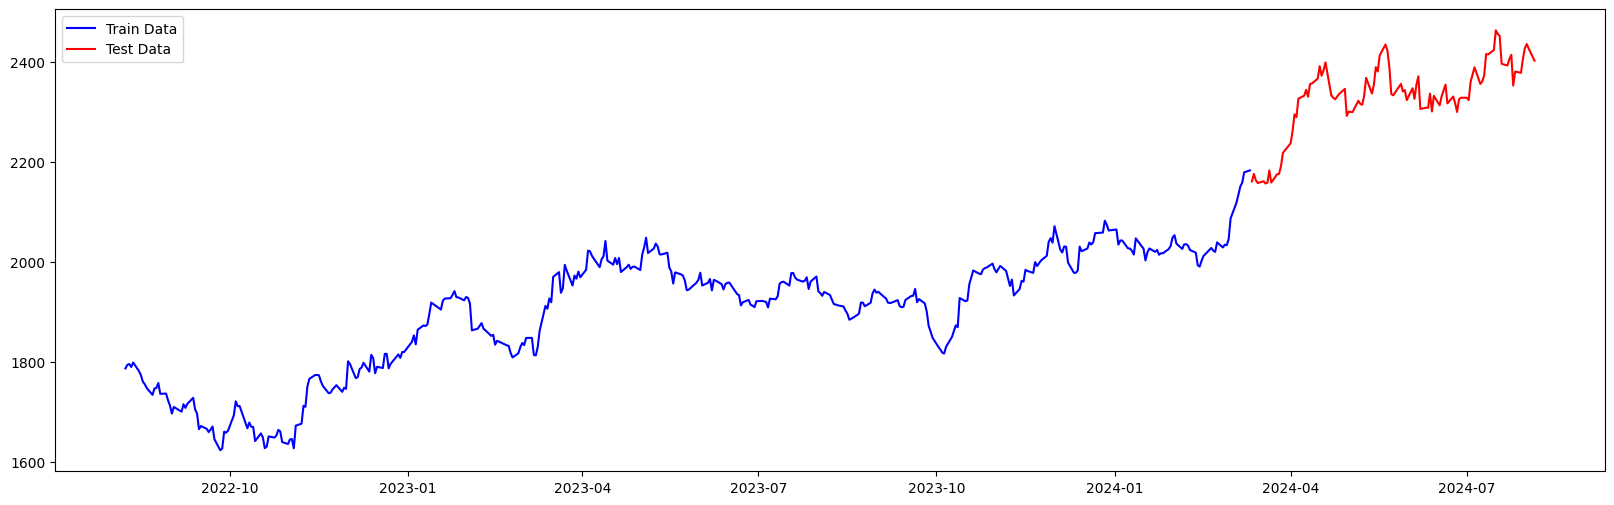

In [ ]:
plt.figure(figsize=(20, 6))
plt.plot(train['ds'], train['y'], label="Train Data", color='blue')
plt.plot(test['ds'], test['y'], label="Test Data", color='red')
plt.legend()
plt.savefig('data.eps')
plt.show()

## Statistical modeling

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from statsforecast.models import AutoETS


autoarima = StatsForecast(
    models=[AutoARIMA(season_length=1)],
    freq='D', # Frequency of your data, 'D' for days
)

start = time.time()
autoarima.fit(train)
end = time.time()
autoarima_train_time = end - start

forecast_horizon = test.shape[0]  # Number of periods to forecast
start = time.time()
autoarima_forecast = autoarima.predict(h=forecast_horizon)
end = time.time()
autoarima_predict_time = end - start

autoets = StatsForecast(
    models=[AutoETS(season_length=1)],
    freq='D', # Frequency of your data, 'D' for days
)

start = time.time()
autoets.fit(train)
end = time.time()
autoets_train_time = end - start

start = time.time()
autoets_forecast = autoets.predict(h=forecast_horizon)
end = time.time()
autoets_predict_time = end - start

print(f"AutoARIMA Training Time: {round(autoarima_train_time, 2)} seconds")
print(f"AutoARIMA Prediction Time: {round(autoarima_predict_time, 2)} seconds")
print(f"AutoETS Training Time: {round(autoets_train_time, 2)} seconds")
print(f"AutoETS Prediction Time: {round(autoets_predict_time, 2)} seconds")

AutoARIMA Training Time: 1.03 seconds
AutoARIMA Prediction Time: 0.01 seconds
AutoETS Training Time: 0.04 seconds
AutoETS Prediction Time: 0.01 seconds


## Machine learning Modeling

In [ ]:
from mlforecast import MLForecast
from mlforecast.target_transforms import AutoDifferences
import lightgbm
import xgboost
from sklearn.ensemble import RandomForestRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import (
    RollingMean, RollingStd, RollingMin, RollingMax, RollingQuantile,
    SeasonalRollingMean, SeasonalRollingStd, SeasonalRollingMin,
    SeasonalRollingMax, SeasonalRollingQuantile,
    ExpandingMean
)


# Define the forecast object with appropriate parameters
mlf = lambda model: MLForecast(
    models=model,
    freq='D',  # Frequency set to daily
    lags=[1, 3, 7, 14],  # Adjust lag features for daily data
    lag_transforms={
        1: [
            RollingMean(window_size=3),
            RollingStd(window_size=3),
            RollingMin(window_size=3),
            RollingMax(window_size=3),
            RollingQuantile(p=0.5, window_size=3),
            ExpandingMean()
        ],
        7: [
            RollingMean(window_size=7),
            RollingStd(window_size=7),
            RollingMin(window_size=7),
            RollingMax(window_size=7),
            RollingQuantile(p=0.5, window_size=7)
        ],
        14: [
            SeasonalRollingMean(season_length=7, window_size=3),
            SeasonalRollingStd(season_length=7, window_size=3),
            SeasonalRollingMin(season_length=7, window_size=3),
            SeasonalRollingMax(season_length=7, window_size=3),
            SeasonalRollingQuantile(p=0.5, season_length=7, window_size=3)
        ]
    },
    date_features=['year', 'month', 'dayofyear'],
    target_transforms=[AutoDifferences(max_diffs=3)]
)


lgb = mlf(lightgbm.LGBMRegressor(verbosity=-1))
xgb = mlf(xgboost.XGBRegressor())
rf = mlf(RandomForestRegressor(random_state=0))

# fit model
start = time.time()
lgb.fit(train)
end = time.time()
lgb_train_time = end - start

start = time.time()
xgb.fit(train)
end = time.time()
xgb_train_time = end - start

start = time.time()
rf.fit(train)
end = time.time()
rf_train_time = end - start

# predict
start = time.time()
lgb_forecast = lgb.predict(forecast_horizon)
end = time.time()
lgb_predict_time = end - start

start = time.time()
xgb_forecast = xgb.predict(forecast_horizon)
end = time.time()
xgb_predict_time = end - start

start = time.time()
rf_forecast = rf.predict(forecast_horizon)
end = time.time()
rf_predict_time = end - start

print(f"LGBMRegressor Training Time: {round(lgb_train_time, 2)} seconds")
print(f"XGBRegressor Training Time: {round(xgb_train_time, 2)} seconds")
print(f"RandomForestRegressor Training Time: {round(rf_train_time, 2)} seconds")
print(f"LGBMRegressor Prediction Time: {round(lgb_predict_time, 2)} seconds")
print(f"XGBRegressor Prediction Time: {round(xgb_predict_time, 2)} seconds")
print(f"RandomForestRegressor Prediction Time: {round(rf_predict_time, 2)} seconds")

LGBMRegressor Training Time: 0.13 seconds
XGBRegressor Training Time: 0.54 seconds
RandomForestRegressor Training Time: 0.88 seconds
LGBMRegressor Prediction Time: 0.47 seconds
XGBRegressor Prediction Time: 1.19 seconds
RandomForestRegressor Prediction Time: 1.56 seconds


## LstmMlp model Forecasting

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler


# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(data[['y']])

# create squence
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

# Define sequence length
seq_length = 10

# Create sequences
X, y = create_sequences(train_scaled, seq_length)

# Split the data into training and test sets
train_size = X.shape[0] - test.shape[0]
X_train, X_test, y_train, y_test = X[:train_size], X[train_size:], y[:train_size], y[train_size:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# LSTM MLP Modeling
model = Sequential()
model.add(LSTM(50, return_sequences=False, input_shape=(seq_length, 1)))
model.add(Dropout(0.2))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
start = time.time()
history = model.fit(X_train, y_train, batch_size=32, epochs=25, validation_data=(X_test, y_test))
end = time.time()
lstm_mlp_train_time = end - start

print(f"LSTM MLP Training Time: {round(lstm_mlp_train_time, 2)} seconds")

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0371 - val_loss: 0.0018
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0067 - val_loss: 0.0431
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0045 - val_loss: 0.0050
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0032 - val_loss: 0.0078
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0032 - val_loss: 0.0049
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0024 - val_loss: 0.0018
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022 - val_loss: 0.0054
Epoch 9/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0022 - val_loss: 0.0022
Epoch 10/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 11/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0018 - val_loss: 0.0019
Epoch 12/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

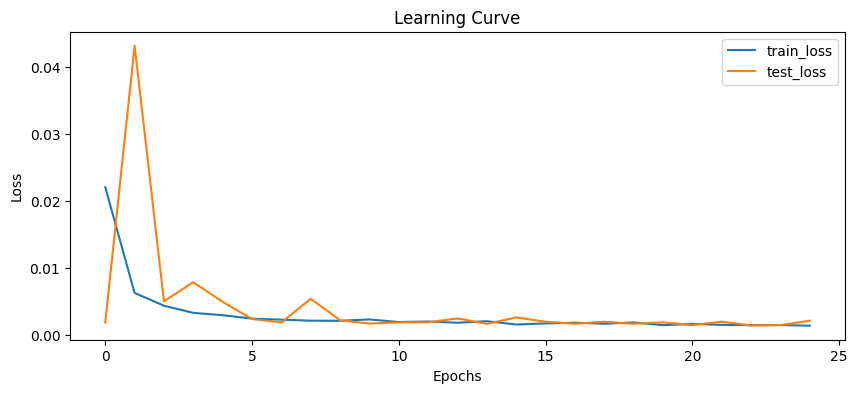

In [ ]:
def learning_curve(train_loss, test_loss):
    return pd.DataFrame({'train_loss': train_loss, 'test_loss': test_loss}).plot(kind='line', figsize=(10, 4), title='Learning Curve')

learning_curve(history.history['loss'], history.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
# Make predictions
start = time.time()
test_predictions = model.predict(X_test)
end = time.time()
lstm_mlp_predict_time = end - start

# Inverse transform the predictions
test_predictions = scaler.inverse_transform(test_predictions)

dl_forecast = pd.concat([test['ds'].reset_index(drop=True),
                         pd.DataFrame({'lstmMlp': test_predictions.flatten()})], axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [ ]:
forecasting = pd.merge(test.drop('unique_id', axis=1), autoarima_forecast.drop('unique_id', axis=1), on='ds')
forecasting = pd.merge(forecasting, autoets_forecast.drop('unique_id', axis=1), on='ds')
forecasting = pd.merge(forecasting, lgb_forecast.drop('unique_id', axis=1), on='ds')
forecasting = pd.merge(forecasting, xgb_forecast.drop('unique_id', axis=1), on='ds')
forecasting = pd.merge(forecasting, rf_forecast.drop('unique_id', axis=1), on='ds')
forecasting = pd.merge(forecasting, dl_forecast, on='ds')
forecasting

,ds,y,AutoARIMA,AutoETS,LGBMRegressor,XGBRegressor,RandomForestRegressor,lstmMlp
0,2024-03-12,2160.399902,2179.992628,2182.49961,2169.189112,2179.776857,2180.933994,2144.228027
1,2024-03-13,2175.399902,2183.790491,2182.49961,2169.342590,2192.382072,2184.849994,2148.315674
2,2024-03-14,2163.000000,2188.078550,2182.49961,2162.577551,2191.654119,2180.679989,2153.648438
3,2024-03-15,2157.300049,2186.768042,2182.49961,2162.766146,2207.324353,2178.426000,2153.849121
4,2024-03-18,2160.699951,2184.631572,2182.49961,2153.484873,2223.665031,2175.152007,2151.670410
...,...,...,...,...,...,...,...,...
65,2024-06-13,2300.199951,2184.337171,2182.49961,2196.854101,2479.158611,2170.584045,2307.905518
66,2024-06-14,2331.399902,2184.459087,2182.49961,2191.043631,2478.670342,2169.961030,2301.294922
67,2024-06-17,2312.399902,2184.229953,2182.49961,2198.782460,2480.575061,2179.605004,2303.621582
68,2024-06-18,2330.399902,2184.360057,2182.49961,2200.485572,2489.158449,2183.006997,2301.506836


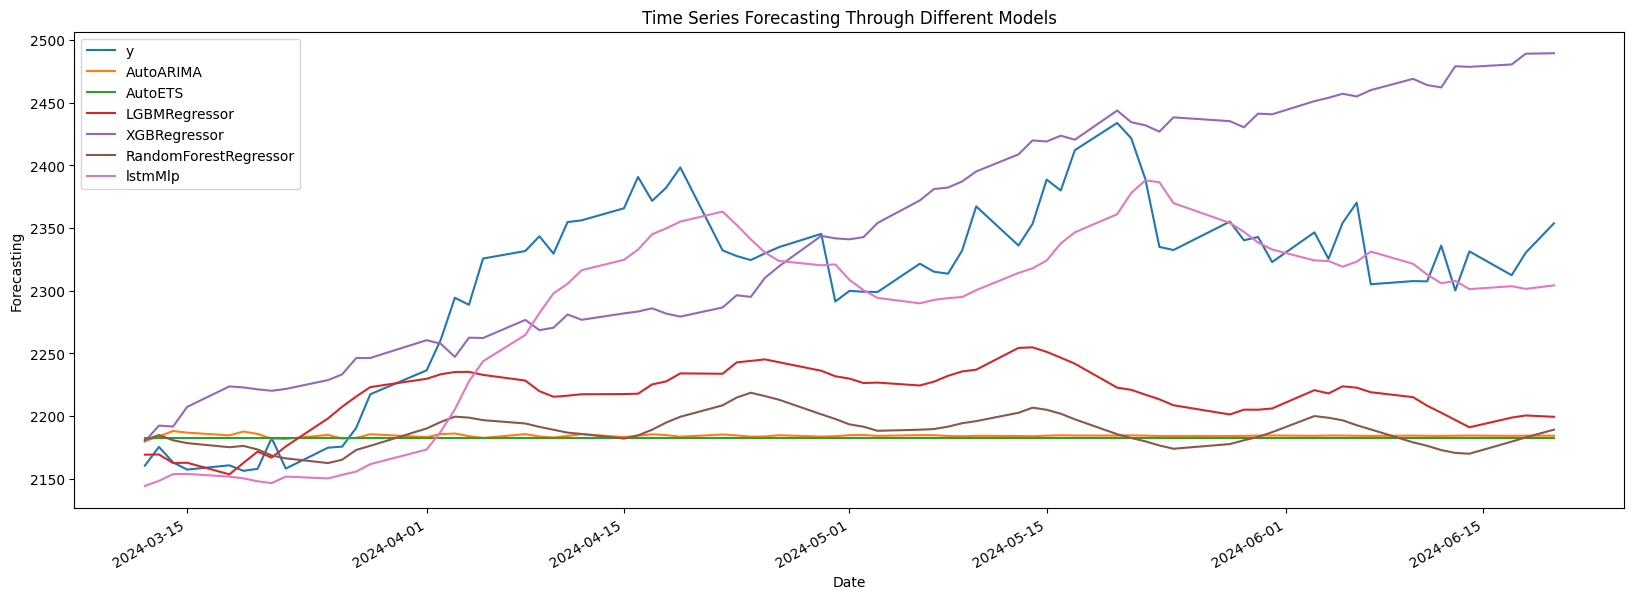

In [ ]:
fig = forecasting.set_index('ds').plot(kind='line', figsize=(20, 7), title='Time Series Forecasting Through Different Models')
plt.xlabel('Date')
plt.ylabel('Forecasting')
plt.savefig('results.eps')
plt.show()

In [ ]:
MAE = lambda actual_values, predicted_values: np.mean(np.abs(actual_values - predicted_values))
RMSE = lambda actual_values, predicted_values: np.sqrt(np.mean((actual_values - predicted_values)**2))
MAPE = lambda actual_values, predicted_values: np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

pd.DataFrame({"MAE": [MAE(forecasting['y'], forecasting['AutoARIMA']),
                      MAE(forecasting['y'], forecasting['AutoETS']),
                      MAE(forecasting['y'], forecasting['LGBMRegressor']),
                      MAE(forecasting['y'], forecasting['XGBRegressor']),
                      MAE(forecasting['y'], forecasting['RandomForestRegressor']),
                      MAE(forecasting['y'], forecasting['lstmMlp'])],

              "RMSE": [RMSE(forecasting['y'], forecasting['AutoARIMA']),
                       RMSE(forecasting['y'], forecasting['AutoETS']),
                       RMSE(forecasting['y'], forecasting['LGBMRegressor']),
                       RMSE(forecasting['y'], forecasting['XGBRegressor']),
                       RMSE(forecasting['y'], forecasting['RandomForestRegressor']),
                       RMSE(forecasting['y'], forecasting['lstmMlp'])],

              "MAPE": [MAPE(forecasting['y'], forecasting['AutoARIMA']),
                       MAPE(forecasting['y'], forecasting['AutoETS']),
                       MAPE(forecasting['y'], forecasting['LGBMRegressor']),
                       MAPE(forecasting['y'], forecasting['XGBRegressor']),
                       MAPE(forecasting['y'], forecasting['RandomForestRegressor']),
                       MAPE(forecasting['y'], forecasting['lstmMlp'])]},
             index=['AutoARIMA', 'AutoETS', 'LGBMRegressor', 'XGBRegressor', 'RandomForestRegressor', 'lstmMlp'])

,MAE,RMSE,MAPE
AutoARIMA,128.994021,143.278824,5.509164
AutoETS,130.230258,144.844320,5.561106
LGBMRegressor,95.555061,109.274536,4.075329
XGBRegressor,69.862792,82.524238,3.019519
RandomForestRegressor,122.742953,137.240894,5.240145
lstmMlp,31.088592,38.279513,1.338955


# Time series forecasting using generative adversarial networks (ForGAN)

**Paper:** https://doi.org/10.1109/ACCESS.2019.2915544

Import the dependencies.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import yfinance as yf
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

Define a function for fixing the random seeds, for reproducibility.

In [ ]:
def set_seeds(seed):
    '''
    Fix the random seeds.
    '''
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)


def set_global_determinism(seed):
    '''
    Fix all sources of randomness.
    '''
    set_seeds(seed=seed)

    os.environ["TF_DETERMINISTIC_OPS"] = "1"
    os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

    #tf.config.threading.set_inter_op_parallelism_threads(1)
    #tf.config.threading.set_intra_op_parallelism_threads(1)

Define the generator architecture.

In [ ]:
class Generator(tf.keras.Model):
    '''
    Generator model.
    '''

    def __init__(self, units, noise_dimension):
        super().__init__()

        # recurrent layer
        self.rnn = tf.keras.layers.LSTM(units=units, return_sequences=False)

        # dense layer
        self.dense = tf.keras.layers.Dense(units=units + noise_dimension, activation="relu")

        # output layer
        self.out = tf.keras.layers.Dense(units=1)

    def call(self, inputs):

        # extract the inputs
        condition, noise = inputs

        # get the condition representation
        representation = self.rnn(condition)

        # extend the condition representation with the noise vector
        representation = tf.concat([representation, noise], axis=-1)

        # get the predicted value
        prediction = self.out(self.dense(representation))

        return prediction

Define the discriminator architecture.

In [ ]:
class Discriminator(tf.keras.Model):
    '''
    Discriminator model.
    '''

    def __init__(self, units):
        super().__init__()

        # recurrent layer
        self.rnn = tf.keras.layers.LSTM(units=units, return_sequences=False)

        # output layer
        self.out = tf.keras.layers.Dense(units=1, activation="sigmoid")

    def call(self, inputs):

        # extract the inputs
        condition, next_value = inputs

        # extend the condition with the next value (either actual/real or predicted/fake)
        condition = tf.concat([condition, tf.expand_dims(next_value, axis=1)], axis=1)

        # get the condition representation
        representation = self.rnn(condition)

        # get the predicted probability
        probability = self.out(representation)

        return probability

Define a custom class for training the model and generating the probabilistic forecasts.

In [ ]:
class ForGAN():
    '''
    ForGAN model.
    '''
    def __init__(self,
                 generator_units,
                 discriminator_units,
                 condition_length,
                 noise_dimension,
                 seed=42):

        self.generator_units = generator_units
        self.discriminator_units = discriminator_units
        self.condition_length = condition_length
        self.noise_dimension = noise_dimension
        self.seed = seed

    def fit(self, x, learning_rate, batch_size, epochs):

        # fix the random seeds
        set_global_determinism(seed=self.seed)

        # scale the time series
        x = x.copy().values
        self.mu = np.mean(x, axis=0)
        self.sigma = np.std(x, axis=0, ddof=1)
        x = (x - self.mu) / self.sigma

        # split the time series into condition sequences and target values
        condition = []
        target = []
        for t in range(self.condition_length, len(x)):
            condition.append(x[t - self.condition_length: t, :])
            target.append(x[t, :])
        condition = np.array(condition)
        target = np.array(target)

        # split the condition sequences and target values into batches
        dataset = tf.data.Dataset.from_tensor_slices((tf.cast(condition, tf.float32), tf.cast(target, tf.float32)))
        dataset = dataset.cache().shuffle(buffer_size=len(target), seed=self.seed).batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

        # build the models
        self.generator_model = Generator(units=self.generator_units, noise_dimension=self.noise_dimension)
        self.discriminator_model = Discriminator(units=self.discriminator_units)

        # instantiate the optimizers
        generator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
        discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

        # define the loss function
        bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

        # define the training loop
        @tf.function
        def train_step(data):
            with tf.GradientTape() as generator_tape, tf.GradientTape() as discriminator_tape:

                # extract the condition sequences and the target values
                condition, target = data

                # generate the noise vector
                noise = tf.random.normal(shape=(len(condition), self.noise_dimension))

                # generate the target values
                prediction = self.generator_model(inputs=[condition, noise])

                # pass the actual and the generated target values to the discriminator
                target_probability = self.discriminator_model(inputs=[condition, target])
                prediction_probability = self.discriminator_model(inputs=[condition, prediction])

                # calculate the generator loss
                generator_loss = bce(y_true=tf.ones_like(prediction_probability), y_pred=prediction_probability)

                # calculate the discriminator loss
                discriminator_loss = bce(y_true=tf.ones_like(target_probability), y_pred=target_probability) + \
                                     bce(y_true=tf.zeros_like(prediction_probability), y_pred=prediction_probability)

            # calculate the gradients
            generator_gradients = generator_tape.gradient(generator_loss, self.generator_model.trainable_variables)
            discriminator_gradients = discriminator_tape.gradient(discriminator_loss, self.discriminator_model.trainable_variables)

            # update the weights
            generator_optimizer.apply_gradients(zip(generator_gradients, self.generator_model.trainable_variables))
            discriminator_optimizer.apply_gradients(zip(discriminator_gradients, self.discriminator_model.trainable_variables))

            return generator_loss, discriminator_loss

        # train the models
        pbar = tqdm(range(epochs))
        for epoch in pbar:
            for data in dataset:
                generator_loss, discriminator_loss = train_step(data)
            pbar.set_description_str("Epoch: {}  Generator Loss: {:.4f}  Discriminator Loss: {:.4f}".format(1 + epoch, generator_loss, discriminator_loss))

    def predict(self, x, samples):

        # fix the random seeds
        set_global_determinism(seed=self.seed)

        # scale the time series
        x = x.copy().values
        x = (x - self.mu) / self.sigma

        # split the time series into condition sequences
        condition = []
        for t in range(self.condition_length, len(x) + 1):
            condition.append(x[t - self.condition_length: t, :])
        condition = np.array(condition)

        # generate the predicted target values
        predictions = []

        # loop across the number of samples to be generated
        for _ in range(samples):

            # generate the noise vector
            noise = tf.random.normal(shape=(len(condition), self.noise_dimension))

            # generate the predicted target values
            prediction = self.generator_model(inputs=[condition, noise]).numpy()

            # transform the predicted target values back to the original scale
            prediction = self.mu + self.sigma * prediction

            # save the predicted target values
            predictions.append(prediction)

        # cast the predicted target values to array
        predictions = np.concatenate(predictions, axis=1)

        return predictions

Define the hyperparameters.

In [ ]:
test_size = 97
generator_units = 256
discriminator_units = 128
condition_length = 5
noise_dimension = 10
learning_rate = 0.001
batch_size = 64
epochs = 100

Download the data.

In [ ]:
num_of_years = 2
end_date = datetime(2024, 8, 6)
state_date = end_date - timedelta(days=365*num_of_years)
gold_ticker = 'GC=F'
dataset = yf.download(gold_ticker, start=state_date, end=end_date)
dataset = dataset[["Close"]].rename(columns={"Close": gold_ticker})

[*********************100%***********************]  1 of 1 completed


In [ ]:
dataset

Price,GC=F
Ticker,GC=F
Date,
2022-08-08,1786.800049
2022-08-09,1794.000000
2022-08-10,1795.599976
2022-08-11,1789.699951
2022-08-12,1798.599976
...,...
2024-07-30,2405.000000
2024-07-31,2426.500000


Split the data.

In [ ]:
training_dataset = dataset.iloc[:- test_size]
test_dataset = dataset.iloc[- test_size - condition_length:-1]

Fit the model to the training set.

In [ ]:
model = ForGAN(
    generator_units=generator_units,
    discriminator_units=discriminator_units,
    condition_length=condition_length,
    noise_dimension=noise_dimension,
)

start = time.time()
model.fit(
    x=training_dataset,
    learning_rate=learning_rate,
    batch_size=batch_size,
    epochs=epochs,
)
end = time.time()
forgan_train_time = end - start

Epoch: 100  Generator Loss: 0.6911  Discriminator Loss: 1.3873: 100%|██████████| 100/100 [00:48<00:00,  2.08it/s]


Generate the one-step-ahead predictions over the test set.

In [ ]:
start = time.time()
predictions = model.predict(x=test_dataset, samples=100)
end = time.time()
forgan_predict_time = end - start

In [ ]:
predictions.shape

(97, 100)

Calculate the summary statistics of the one-step-ahead predictions.

In [ ]:
predictions = pd.DataFrame(
    data={
        "actual": dataset.iloc[- test_size:].values.flatten(),
        "median": np.median(predictions, axis=1),
        "q005": np.quantile(predictions, 0.005, axis=1),
        "q995": np.quantile(predictions, 0.995, axis=1),
        "q10": np.quantile(predictions, 0.10, axis=1),
        "q90": np.quantile(predictions, 0.90, axis=1),
    },
    index=dataset.index[- test_size:]
)

In [ ]:
predictions.shape

(97, 6)

In [ ]:
predictions.head()

,actual,median,q005,q995,q10,q90
Date,,,,,,
2024-03-18,2160.699951,2117.738214,2100.400280,2154.484785,2107.175052,2133.873864
2024-03-19,2156.300049,2116.158212,2099.798588,2143.091236,2105.349197,2131.221808
2024-03-20,2157.899902,2116.006108,2098.332867,2159.776718,2103.609876,2129.716227
2024-03-21,2182.399902,2110.963929,2094.391425,2137.790242,2099.214873,2126.332283
2024-03-22,2158.100098,2113.441292,2098.453446,2136.989363,2103.188435,2125.283553


Calculate the performance metrics of the one-step-ahead predictions.

In [ ]:
MAE = lambda actual_values, predicted_values: np.mean(np.abs(actual_values - predicted_values))
RMSE = lambda actual_values, predicted_values: np.sqrt(np.mean((actual_values - predicted_values)**2))
MAPE = lambda actual_values, predicted_values: np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100

metrics = pd.DataFrame(
    columns=["Metric", "Value"],
    data=[
        {"Metric": "RMSE", "Value": format(RMSE(predictions["actual"], predictions["median"]), ".4f")},
        {"Metric": "MAE", "Value": format(MAE(predictions["actual"], predictions["median"]), ".4f")},
        {"Metric": "MAPE", "Value": format(MAPE(predictions["actual"], predictions["median"]), ".4f")},
    ]
)

In [ ]:
metrics

,Metric,Value
0,RMSE,118.6855
1,MAE,113.4757
2,MAPE,4.8236


Visualize the one-step-ahead predictions.

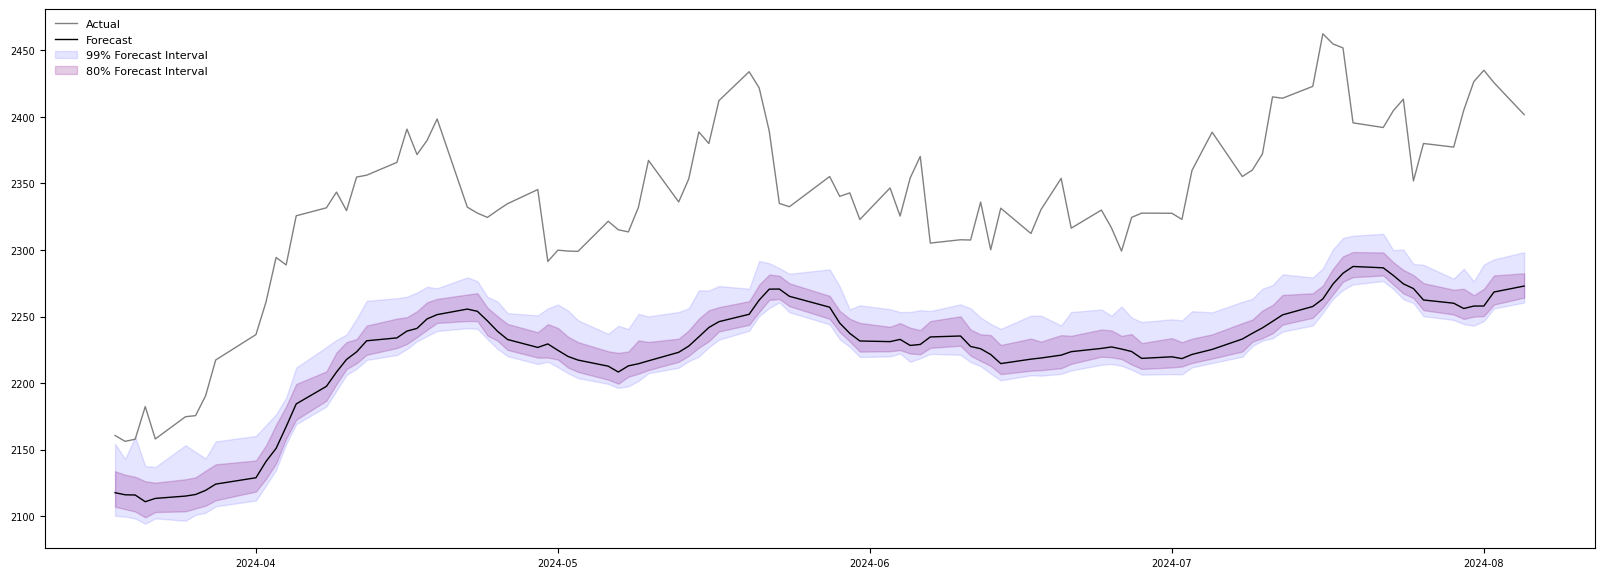

In [ ]:
plt.subplots(figsize=(20, 7))
plt.plot(predictions.index, predictions["actual"], lw=1, color="gray", label="Actual")
plt.plot(predictions.index, predictions["median"], lw=1, color="black", label="Forecast")
plt.fill_between(predictions.index, predictions["q005"], predictions["q995"], color="blue", alpha=0.1, label="99% Forecast Interval")
plt.fill_between(predictions.index, predictions["q10"], predictions["q90"], color="purple", alpha=0.2, label="80% Forecast Interval")
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.legend(frameon=False, fontsize=8)
plt.savefig('ForGAN.eps')
plt.show()

In [ ]:
ForGAN_forecasting = predictions[['median']].rename({'median':'ForGAN'}, axis=1)

In [ ]:
ForGAN_forecasting

,ForGAN
Date,
2024-03-18,2117.738214
2024-03-19,2116.158212
2024-03-20,2116.006108
2024-03-21,2110.963929
2024-03-22,2113.441292
...,...
2024-07-30,2256.068106
2024-07-31,2257.908091
2024-08-01,2257.954462


# Time series forecasting using MambaStock

In [ ]:
!git clone https://github.com/zshicode/MambaStock

Cloning into 'MambaStock'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 33 (delta 6), reused 5 (delta 5), pack-reused 22 (from 1)
Receiving objects: 100% (33/33), 625.99 KiB | 3.18 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [ ]:
cd /content/MambaStock

/content/MambaStock


[*********************100%***********************]  1 of 1 completed


Epoch 10 | Lossp: 0.0031
Epoch 20 | Lossp: 0.0095
Epoch 30 | Lossp: 0.0059
Epoch 40 | Lossp: 0.0014
Epoch 50 | Lossp: 0.0001
Epoch 60 | Lossp: 0.0003
Epoch 70 | Lossp: 0.0001
Epoch 80 | Lossp: 0.0001
Epoch 90 | Lossp: 0.0001
Training start 2022-08-09 00:00:00
Training end 2024-03-15 00:00:00
Testing start 2024-03-18 00:00:00
Testing end 2024-08-05 00:00:00
MSE RMSE MAE R2
635.8858 25.2168 20.3332 0.8606


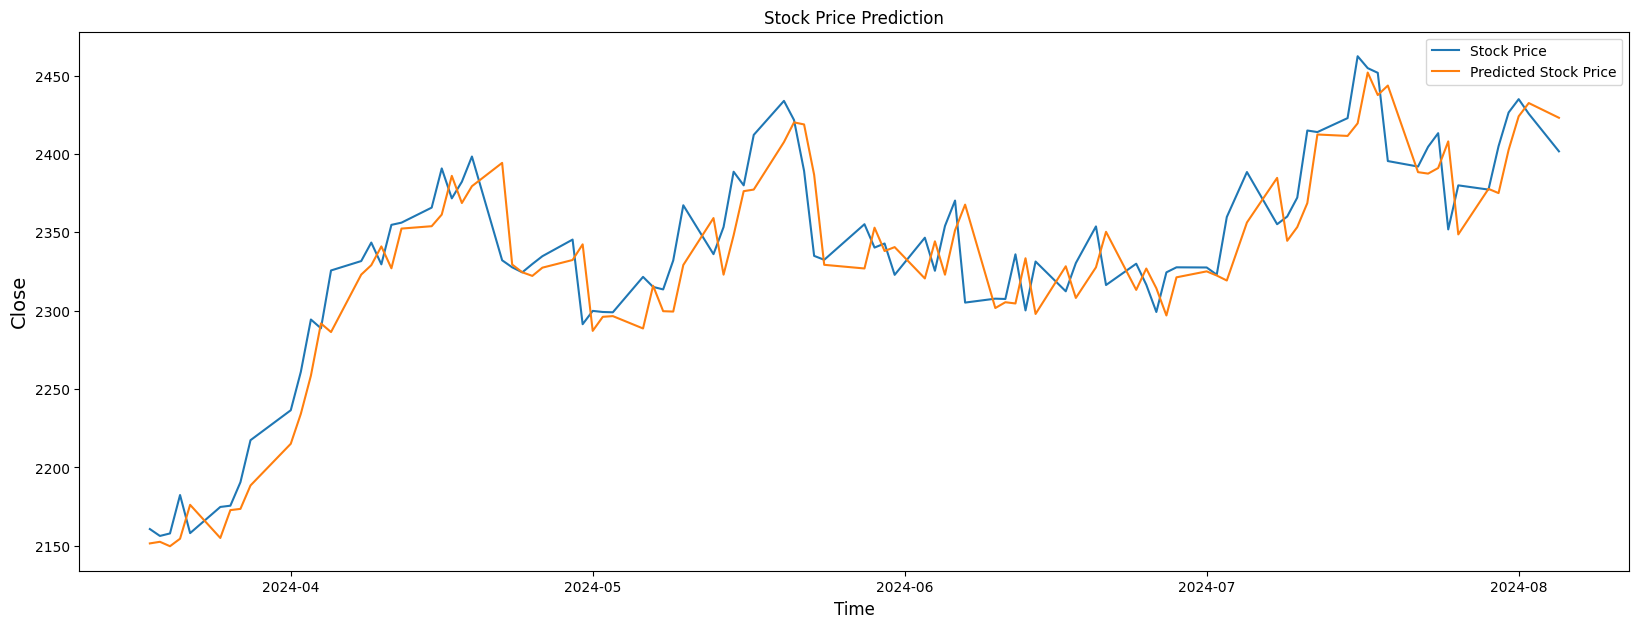

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from mamba import Mamba, MambaConfig
from datetime import timedelta, datetime
import yfinance as yf
from sklearn.model_selection import train_test_split
import time


# set configuration
cuda = False         # CUDA training
seed = 1             # Random seed
epochs = 100         # Number of epochs to train
lr = 0.01            # Learing Rate
wd = 1e-5            # Weight decay (L2 loss on parameters)
hidden = 16          # Dimension of representation
layer = 2            # Number of layers
n_test = 97         # Size of test set


def evaluation_metric(y_test,y_hat):
    MSE = mean_squared_error(y_test, y_hat)
    RMSE = MSE**0.5
    MAE = mean_absolute_error(y_test,y_hat)
    R2 = r2_score(y_test,y_hat)
    print('%.4f %.4f %.4f %.4f' % (MSE,RMSE,MAE,R2))

def set_seed(seed,cuda):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if cuda:
        torch.cuda.manual_seed(seed)

def dateinf(series, n_test):
    lt = len(series)
    print('Training start',series[0])
    print('Training end',series[lt-n_test-1])
    print('Testing start',series[lt-n_test])
    print('Testing end',series[lt-1])

set_seed(seed, cuda)

class Net(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        self.config = MambaConfig(d_model=hidden, n_layers=layer)
        self.mamba = nn.Sequential(
            nn.Linear(in_dim,hidden),
            Mamba(self.config),
            nn.Linear(hidden,out_dim),
            nn.Tanh()
        )

    def forward(self,x):
        x = self.mamba(x)
        return x.flatten()


def PredictWithData(trainX, trainy, testX):
    clf = Net(len(trainX[0]),1)
    opt = torch.optim.Adam(clf.parameters(),lr=lr,weight_decay=wd)
    xt = torch.from_numpy(trainX).float().unsqueeze(0)
    xv = torch.from_numpy(testX).float().unsqueeze(0)
    yt = torch.from_numpy(trainy).float()
    if cuda:
        clf = clf.cuda()
        xt = xt.cuda()
        xv = xv.cuda()
        yt = yt.cuda()

    start = time.time()
    for e in range(epochs):
        clf.train()
        z = clf(xt)
        loss = F.mse_loss(z,yt)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if e%10 == 0 and e!=0:
            print('Epoch %d | Lossp: %.4f' % (e, loss.item()))
    end = time.time()
    global MambaStock_train_time
    MambaStock_train_time = end - start


    clf.eval()
    mat = clf(xv)
    if cuda: mat = mat.cpu()
    start = time.time()
    yhat = mat.detach().numpy().flatten()
    end = time.time()
    global MambaStock_predict_time
    MambaStock_predict_time = end - start
    return yhat


# Detect how much data we want in historical data (ex. two year of data)
num_of_years = 2
# Get end date
end_date = datetime(2024, 8, 6)
# Get start date
state_date = end_date - timedelta(days=365*num_of_years)
# Ticker symbol
gold_ticker = 'GC=F'
# Fetch historical gold data as pandas dataframe
df = yf.download(gold_ticker, start=state_date, end=end_date)

# create extra features
df['pre_close'] = df['Close'].shift(1)
df['change'] =  df['Close'].values.flatten() - df['pre_close'].values.flatten()
df['pct_chg'] = df['change'] / df['pre_close'] * 100
df['amount'] = df['Close'] * df['Volume']


# drop nan values
df.dropna(inplace=True)

data = df.copy()
close = data.pop('Close').values
ratechg = data['pct_chg'].apply(lambda x:0.01*x).values
data.drop(columns=['pre_close','change','pct_chg'],inplace=True)
dat = data.iloc[:,2:].values
trainX, testX = dat[:-n_test, :], dat[-n_test:, :]
trainy = ratechg[:-n_test]
predictions = PredictWithData(trainX, trainy, testX)
time = data.index[-n_test:]
data1 = close[-n_test:]
finalpredicted_stock_price = []
pred = close[-n_test-1]
for i in range(n_test):
    pred = close[-n_test-1+i]*(1+predictions[i])
    finalpredicted_stock_price.append(pred)


dateinf(data.index, n_test)
print('MSE RMSE MAE R2')
evaluation_metric(data1, finalpredicted_stock_price)
plt.figure(figsize=(20, 7))
plt.plot(time, data1, label='Stock Price')
plt.plot(time, finalpredicted_stock_price, label='Predicted Stock Price')
plt.title('Stock Price Prediction')
plt.xlabel('Time', fontsize=12, verticalalignment='top')
plt.ylabel('Close', fontsize=14, horizontalalignment='center')
plt.legend()
plt.show()

In [ ]:
MambaStock_forecasting = pd.DataFrame({'MambaStock':[float(value[0]) for value in finalpredicted_stock_price]}, index=time)
MambaStock_forecasting

,MambaStock
Date,
2024-03-18,2151.534293
2024-03-19,2152.565845
2024-03-20,2149.739593
2024-03-21,2154.524119
2024-03-22,2176.151583
...,...
2024-07-30,2375.057959
2024-07-31,2402.659681
2024-08-01,2424.069192


# The final results

In [ ]:
forecasting = forecasting.rename({'ds':'Date'}, axis=1)

In [ ]:
ForGAN_forecasting = ForGAN_forecasting.reset_index()

In [ ]:
MambaStock_forecasting = MambaStock_forecasting.reset_index()

In [ ]:
forecasts = pd.merge(forecasting, ForGAN_forecasting, on='Date')
forecasts = pd.merge(forecasts, MambaStock_forecasting, on='Date')
forecasts

,Date,y,AutoARIMA,AutoETS,LGBMRegressor,XGBRegressor,RandomForestRegressor,lstmMlp,index,ForGAN,MambaStock
0,2024-03-18,2160.699951,2184.631572,2182.49961,2153.484873,2223.665031,2175.152007,2151.670410,0,2117.738214,2151.534293
1,2024-03-19,2156.300049,2187.648772,2182.49961,2162.672254,2222.861556,2176.182007,2150.295166,1,2116.158212,2152.565845
2,2024-03-20,2157.899902,2185.765543,2182.49961,2171.647279,2221.321629,2173.348010,2147.977295,2,2116.006108,2149.739593
3,2024-03-21,2182.399902,2181.992960,2182.49961,2166.811497,2220.185732,2168.561017,2146.502686,3,2110.963929,2154.524119
4,2024-03-22,2158.100098,2181.792729,2182.49961,2175.766688,2221.634082,2166.241008,2151.707031,4,2113.441292,2176.151583
...,...,...,...,...,...,...,...,...,...,...,...
61,2024-06-13,2300.199951,2184.337171,2182.49961,2196.854101,2479.158611,2170.584045,2307.905518,61,2221.531205,2333.491655
62,2024-06-14,2331.399902,2184.459087,2182.49961,2191.043631,2478.670342,2169.961030,2301.294922,62,2214.700200,2297.942968
63,2024-06-17,2312.399902,2184.229953,2182.49961,2198.782460,2480.575061,2179.605004,2303.621582,63,2218.034043,2328.363438
64,2024-06-18,2330.399902,2184.360057,2182.49961,2200.485572,2489.158449,2183.006997,2301.506836,64,2218.901035,2308.160396


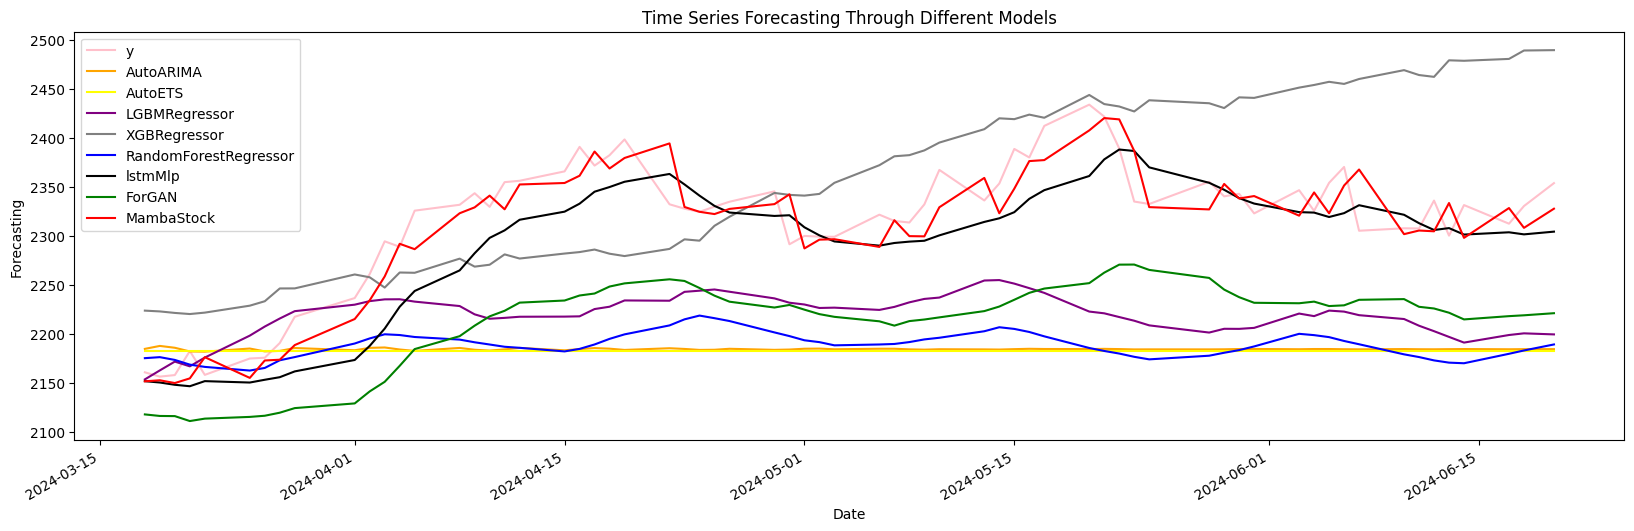

In [ ]:
colors = ['pink', 'orange', 'yellow', 'purple', 'grey', 'blue', 'black', 'green', 'red']
fig = forecasts.drop('index', axis=1).plot(kind='line', x='Date', figsize=(20, 6), title='Time Series Forecasting Through Different Models', color=colors)
plt.xlabel('Date')
plt.ylabel('Forecasting')
plt.savefig('results.eps')
plt.show()

In [ ]:
pd.DataFrame({"MAE": [MAE(forecasts['y'], forecasts['AutoARIMA']),
                      MAE(forecasts['y'], forecasts['AutoETS']),
                      MAE(forecasts['y'], forecasts['LGBMRegressor']),
                      MAE(forecasts['y'], forecasts['XGBRegressor']),
                      MAE(forecasts['y'], forecasts['RandomForestRegressor']),
                      MAE(forecasts['y'], forecasts['lstmMlp']),
                      MAE(forecasts['y'], forecasts['ForGAN']),
                      MAE(forecasts['y'], forecasts['MambaStock'])],

              "RMSE": [RMSE(forecasts['y'], forecasts['AutoARIMA']),
                       RMSE(forecasts['y'], forecasts['AutoETS']),
                       RMSE(forecasts['y'], forecasts['LGBMRegressor']),
                       RMSE(forecasts['y'], forecasts['XGBRegressor']),
                       RMSE(forecasts['y'], forecasts['RandomForestRegressor']),
                       RMSE(forecasts['y'], forecasts['lstmMlp']),
                       RMSE(forecasts['y'], forecasts['ForGAN']),
                       RMSE(forecasts['y'], forecasts['MambaStock'])],

              "MAPE": [MAPE(forecasts['y'], forecasts['AutoARIMA']),
                       MAPE(forecasts['y'], forecasts['AutoETS']),
                       MAPE(forecasts['y'], forecasts['LGBMRegressor']),
                       MAPE(forecasts['y'], forecasts['XGBRegressor']),
                       MAPE(forecasts['y'], forecasts['RandomForestRegressor']),
                       MAPE(forecasts['y'], forecasts['lstmMlp']),
                       MAPE(forecasts['y'], forecasts['ForGAN']),
                       MAPE(forecasts['y'], forecasts['MambaStock'])]},
             index=['AutoARIMA', 'AutoETS', 'LGBMRegressor', 'XGBRegressor', 'RandomForestRegressor', 'lstmMlp', 'ForGAN', 'MambaStock'])

,MAE,RMSE,MAPE
AutoARIMA,135.561389,147.456513,5.785204
AutoETS,137.003326,149.090035,5.846341
LGBMRegressor,101.032109,112.527484,4.307800
XGBRegressor,72.353908,84.632015,3.121897
RandomForestRegressor,129.139645,141.270457,5.509525
lstmMlp,32.123376,39.211554,1.380924
ForGAN,105.019862,109.993666,4.505983
MambaStock,20.177056,25.015194,0.869096


In [ ]:
# train time amd predict time comparsion
pd.DataFrame({"Train Time": [autoarima_train_time, autoets_train_time, lgb_train_time, xgb_train_time, rf_train_time,lstm_mlp_train_time, forgan_train_time, MambaStock_train_time],
              "Predict Time": [autoarima_predict_time, autoarima_predict_time, lgb_predict_time, xgb_predict_time, rf_predict_time, lstm_mlp_train_time, forgan_predict_time, MambaStock_predict_time]},
             index=['Auto', 'AutoETS', 'LGBMRegressor', 'XGBRegressor', 'RandomForestRegressor', 'lstmMlp', 'ForGAN', 'MambaStock'])

,Train Time,Predict Time
Auto,1.034154,0.009494
AutoETS,0.038611,0.009494
LGBMRegressor,0.132200,0.466338
XGBRegressor,0.544326,1.190150
RandomForestRegressor,0.884210,1.562109
lstmMlp,9.483830,9.483830
ForGAN,48.274216,5.420596
MambaStock,4.326154,0.000058
